# Parcel-wise independent Welch t-tests

Compare expW weighted degree between Healthy and Unhealthy subjects at each parcel.

Subjects come directly from the JSON test cohorts and must have complete graph outputs. There is no pairing or second matching step. BH-FDR controls multiple comparisons across parcels.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = next(
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "data" / "database_finale_labels_corrette.csv").is_file()
)
DATA_FILE = PROJECT_ROOT / "data" / "database_finale_labels_corrette.csv"
SPLITS_FILE = PROJECT_ROOT / "data" / "splits.json"
FEATURE_ROOT = PROJECT_ROOT / "outputs" / "wasserstein_weighted_degrees_expw"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "statistics"


In [2]:
subject_dirs = {
    folder.name: folder
    for folder in FEATURE_ROOT.glob("sub-*")
    if all((folder / name).is_file() for name in (
        "weighted_degree.dat", "parcel_order.txt", "metadata.json"
    ))
}

splits = json.loads(SPLITS_FILE.read_text())
test_healthy = {f"sub-{item}" for item in splits["test_healthy"]}
test_unhealthy = {f"sub-{item}" for item in splits["test_unhealthy"]}
if test_healthy & test_unhealthy:
    raise ValueError("Healthy and Unhealthy test cohorts overlap")

selected_healthy = sorted(test_healthy & subject_dirs.keys())
selected_unhealthy = sorted(test_unhealthy & subject_dirs.keys())

database = pd.read_csv(DATA_FILE)
database["subject_id"] = "sub-" + database["OASISID"].astype(str).str.removeprefix("OAS3")
cohort = database.set_index("subject_id").reindex(selected_healthy + selected_unhealthy)

if cohort["HStatus"].isna().any():
    raise ValueError("Missing group labels for selected subjects")
if not (cohort.loc[selected_healthy, "HStatus"] == "Healthy").all():
    raise ValueError("Healthy test cohort contains an incorrect group label")
if not (cohort.loc[selected_unhealthy, "HStatus"] == "Unhealthy").all():
    raise ValueError("Unhealthy test cohort contains an incorrect group label")

pd.DataFrame([{
    "healthy_in_json": len(test_healthy),
    "unhealthy_in_json": len(test_unhealthy),
    "healthy_with_complete_outputs": len(selected_healthy),
    "unhealthy_with_complete_outputs": len(selected_unhealthy),
}])

,healthy_in_json,unhealthy_in_json,healthy_with_complete_outputs,unhealthy_with_complete_outputs
0,150,150,137,130


In [3]:
subjects = selected_healthy + selected_unhealthy
metadata = [
    json.loads((subject_dirs[subject] / "metadata.json").read_text())
    for subject in subjects
]
if {item["similarity_formula"] for item in metadata} != {"exp(-W)"}:
    raise ValueError("Expected exp(-W) weighted-degree outputs")
if len({item["parcel_order_sha256"] for item in metadata}) != 1:
    raise ValueError("Parcel order differs across subjects")

parcel_ids = (subject_dirs[subjects[0]] / "parcel_order.txt").read_text().splitlines()
parcel_count = len(parcel_ids)

def load_group(subject_ids):
    matrix = np.empty((len(subject_ids), parcel_count), dtype=np.float64)
    for row, subject in enumerate(subject_ids):
        values = np.fromfile(subject_dirs[subject] / "weighted_degree.dat", dtype=np.float64)
        if values.size != parcel_count or not np.isfinite(values).all():
            raise ValueError(f"Invalid weighted degree: {subject}")
        matrix[row] = values
    return matrix

healthy = load_group(selected_healthy)
unhealthy = load_group(selected_unhealthy)

{"healthy_shape": healthy.shape, "unhealthy_shape": unhealthy.shape}

{'healthy_shape': (137, 83442), 'unhealthy_shape': (130, 83442)}

In [4]:
welch = stats.ttest_ind(
    unhealthy,
    healthy,
    axis=0,
    equal_var=False,
    alternative="two-sided",
)
welch_p = np.where(np.isfinite(welch.pvalue), welch.pvalue, 1.0)
welch_q = multipletests(welch_p, method="fdr_bh")[1]
survives_fdr = welch_q < 0.05

healthy_mean = healthy.mean(axis=0)
unhealthy_mean = unhealthy.mean(axis=0)
mean_difference = unhealthy_mean - healthy_mean
healthy_var = healthy.var(axis=0, ddof=1)
unhealthy_var = unhealthy.var(axis=0, ddof=1)
pooled_sd = np.sqrt(
    ((len(healthy) - 1) * healthy_var + (len(unhealthy) - 1) * unhealthy_var)
    / (len(healthy) + len(unhealthy) - 2)
)
cohens_d = np.divide(
    mean_difference,
    pooled_sd,
    out=np.full(parcel_count, np.nan),
    where=pooled_sd > 0,
)
hedges_g = cohens_d * (
    1 - 3 / (4 * (len(healthy) + len(unhealthy)) - 9)
)

results = pd.DataFrame({
    "parcel_id": parcel_ids,
    "healthy_mean": healthy_mean,
    "unhealthy_mean": unhealthy_mean,
    "mean_group_difference": mean_difference,
    "hedges_g": hedges_g,
    "welch_t_statistic": welch.statistic,
    "welch_p": welch_p,
    "welch_q_bh": welch_q,
    "welch_survives_fdr": survives_fdr,
})

summary = pd.DataFrame([{
    "comparison": "Independent Welch t-test: Unhealthy vs Healthy",
    "healthy_subjects": len(healthy),
    "unhealthy_subjects": len(unhealthy),
    "parcels": parcel_count,
    "surviving_parcels_bh_fdr_0.05": int(survives_fdr.sum()),
    "percent_of_all_parcels": 100 * survives_fdr.mean(),
}])
summary.round(2)

,comparison,healthy_subjects,unhealthy_subjects,parcels,surviving_parcels_bh_fdr_0.05,percent_of_all_parcels
0,Independent Welch t-test: Unhealthy vs Healthy,137,130,83442,1283,1.54


In [5]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
parcel_file = RESULTS_DIR / "weighted_degree_expW_independent_welch_tests.csv"
summary_file = RESULTS_DIR / "weighted_degree_expW_independent_welch_summary.csv"

results.to_csv(parcel_file, index=False)
summary.to_csv(summary_file, index=False)

display(results.sort_values("welch_q_bh").head(10).round(6))
pd.Series({"parcel_results": parcel_file, "summary": summary_file})

,parcel_id,healthy_mean,unhealthy_mean,mean_group_difference,hedges_g,welch_t_statistic,welch_p,welch_q_bh,welch_survives_fdr
32827,label_18/roi_32827,0.728280,0.692443,-0.035838,-0.736260,-5.957494,0.000000,0.000887,True
8967,label_3/roi_8967,0.707730,0.658536,-0.049195,-0.701055,-5.673812,0.000000,0.001266,True
73174,label_42/roi_73174,0.736122,0.709745,-0.026376,-0.702287,-5.692205,0.000000,0.001266,True
80924,label_49/roi_80924,0.678479,0.610469,-0.068010,-0.674644,-5.470282,0.000000,0.002003,True
80923,label_49/roi_80923,0.688823,0.636653,-0.052171,-0.678117,-5.507364,0.000000,0.002003,True
28877,label_10/roi_28877,0.708192,0.661160,-0.047032,-0.628517,-5.084648,0.000001,0.003184,True
23691,label_4/roi_23691,0.605423,0.498637,-0.106786,-0.629961,-5.133157,0.000001,0.003184,True
23533,label_4/roi_23533,0.614862,0.512482,-0.102380,-0.629049,-5.116781,0.000001,0.003184,True
75913,label_43/roi_75913,0.665666,0.575994,-0.089672,-0.640039,-5.191391,0.000000,0.003184,True
81296,label_49/roi_81296,0.727917,0.700374,-0.027543,-0.639925,-5.168993,0.000001,0.003184,True


parcel_results    /home/lucagalli/Projects/parcellating_dbm/outp...
summary           /home/lucagalli/Projects/parcellating_dbm/outp...
dtype: object

## Thresholded Version

In [6]:
THRESHOLDED_ROOT = PROJECT_ROOT / "outputs" / "thresholded_weighted_degree"
THRESHOLDED_RESULTS_DIR = PROJECT_ROOT / "outputs" / "statistics_thresholded_weighted_degree"

def load_degree_matrix(subject_ids, directories, expected_parcels):
    matrix = np.empty((len(subject_ids), expected_parcels), dtype=np.float64)
    for row, subject in enumerate(subject_ids):
        values = np.fromfile(directories[subject] / "weighted_degree.dat", dtype=np.float64)
        if values.size != expected_parcels or not np.isfinite(values).all():
            raise ValueError(f"Invalid weighted degree: {subject}")
        matrix[row] = values
    return matrix

def compute_welch_statistics(healthy_matrix, unhealthy_matrix, current_parcel_ids):
    welch = stats.ttest_ind(
        unhealthy_matrix,
        healthy_matrix,
        axis=0,
        equal_var=False,
        alternative="two-sided",
    )
    welch_p = np.where(np.isfinite(welch.pvalue), welch.pvalue, 1.0)
    welch_q = multipletests(welch_p, method="fdr_bh")[1]
    survives_fdr = welch_q < 0.05

    healthy_mean = healthy_matrix.mean(axis=0)
    unhealthy_mean = unhealthy_matrix.mean(axis=0)
    mean_difference = unhealthy_mean - healthy_mean
    healthy_var = healthy_matrix.var(axis=0, ddof=1)
    unhealthy_var = unhealthy_matrix.var(axis=0, ddof=1)
    pooled_sd = np.sqrt(
        ((len(healthy_matrix) - 1) * healthy_var
         + (len(unhealthy_matrix) - 1) * unhealthy_var)
        / (len(healthy_matrix) + len(unhealthy_matrix) - 2)
    )
    cohens_d = np.divide(
        mean_difference,
        pooled_sd,
        out=np.full(len(current_parcel_ids), np.nan),
        where=pooled_sd > 0,
    )
    hedges_g = cohens_d * (
        1 - 3 / (4 * (len(healthy_matrix) + len(unhealthy_matrix)) - 9)
    )

    parcel_results = pd.DataFrame({
        "parcel_id": current_parcel_ids,
        "healthy_mean": healthy_mean,
        "unhealthy_mean": unhealthy_mean,
        "mean_group_difference": mean_difference,
        "hedges_g": hedges_g,
        "welch_t_statistic": welch.statistic,
        "welch_p": welch_p,
        "welch_q_bh": welch_q,
        "welch_survives_fdr": survives_fdr,
    })
    test_summary = pd.DataFrame([{
        "comparison": "Independent Welch t-test: Unhealthy vs Healthy",
        "healthy_subjects": len(healthy_matrix),
        "unhealthy_subjects": len(unhealthy_matrix),
        "parcels": len(current_parcel_ids),
        "surviving_parcels_bh_fdr_0.05": int(survives_fdr.sum()),
        "percent_of_all_parcels": 100 * survives_fdr.mean(),
    }])
    return parcel_results, test_summary

percentile_folders = sorted(
    folder for folder in THRESHOLDED_ROOT.glob("percentile_*")
    if folder.is_dir()
)
thresholded_summaries = []

for percentile_folder in percentile_folders:
    percentile_value = int(percentile_folder.name.removeprefix("percentile_"))
    percentile_subject_dirs = {
        folder.name: folder
        for folder in percentile_folder.glob("sub-*")
        if all((folder / name).is_file() for name in (
            "weighted_degree.dat", "parcel_order.txt", "metadata.json"
        ))
    }
    percentile_healthy = sorted(test_healthy & percentile_subject_dirs.keys())
    percentile_unhealthy = sorted(test_unhealthy & percentile_subject_dirs.keys())
    if len(percentile_healthy) < 2 or len(percentile_unhealthy) < 2:
        raise ValueError(f"Insufficient subjects in {percentile_folder.name}")

    current_subjects = percentile_healthy + percentile_unhealthy
    current_metadata = [
        json.loads((percentile_subject_dirs[subject] / "metadata.json").read_text())
        for subject in current_subjects
    ]
    if {item["similarity_formula"] for item in current_metadata} != {"exp(-W)"}:
        raise ValueError(f"Unexpected similarity formula in {percentile_folder.name}")
    if {item["percentile"] for item in current_metadata} != {percentile_value}:
        raise ValueError(f"Incorrect metadata percentile in {percentile_folder.name}")
    if len({item["parcel_order_sha256"] for item in current_metadata}) != 1:
        raise ValueError(f"Parcel order differs in {percentile_folder.name}")

    current_parcel_ids = (
        percentile_subject_dirs[current_subjects[0]] / "parcel_order.txt"
    ).read_text().splitlines()
    current_parcel_count = len(current_parcel_ids)
    healthy_matrix = load_degree_matrix(
        percentile_healthy, percentile_subject_dirs, current_parcel_count
    )
    unhealthy_matrix = load_degree_matrix(
        percentile_unhealthy, percentile_subject_dirs, current_parcel_count
    )
    percentile_results, percentile_summary = compute_welch_statistics(
        healthy_matrix, unhealthy_matrix, current_parcel_ids
    )
    percentile_summary.insert(0, "percentile", percentile_value)
    percentile_summary["similarity_threshold_min"] = min(
        item["similarity_threshold"] for item in current_metadata
    )
    percentile_summary["similarity_threshold_max"] = max(
        item["similarity_threshold"] for item in current_metadata
    )

    output_dir = THRESHOLDED_RESULTS_DIR / percentile_folder.name
    output_dir.mkdir(parents=True, exist_ok=True)
    percentile_results.to_csv(
        output_dir / "thresholded_weighted_degree_independent_welch_tests.csv",
        index=False,
    )
    percentile_summary.to_csv(
        output_dir / "thresholded_weighted_degree_independent_welch_summary.csv",
        index=False,
    )
    thresholded_summaries.append(percentile_summary.iloc[0].to_dict())
    del healthy_matrix, unhealthy_matrix, percentile_results

thresholded_summary = pd.DataFrame(thresholded_summaries)
display(thresholded_summary.round(4))
THRESHOLDED_RESULTS_DIR


,percentile,comparison,healthy_subjects,unhealthy_subjects,parcels,surviving_parcels_bh_fdr_0.05,percent_of_all_parcels,similarity_threshold_min,similarity_threshold_max
0,10,Independent Welch t-test: Unhealthy vs Healthy,121,121,83442,235,0.2816,0.3389,0.4543
1,20,Independent Welch t-test: Unhealthy vs Healthy,121,121,83442,232,0.2780,0.4393,0.5468
2,40,Independent Welch t-test: Unhealthy vs Healthy,121,121,83442,213,0.2553,0.5881,0.6761
3,80,Independent Welch t-test: Unhealthy vs Healthy,121,121,83442,204,0.2445,0.8383,0.8794


PosixPath('/home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree')

## Thresholded weighted-degree descriptives

Variance is calculated across subjects for each parcel and then averaged across parcels. Parcel counts compare the two group means.

In [7]:
percentile_descriptives = []

for percentile_folder in percentile_folders:
    percentile = int(percentile_folder.name.removeprefix("percentile_"))
    subject_dirs = {
        folder.name: folder
        for folder in percentile_folder.glob("sub-*")
        if (folder / "weighted_degree.dat").is_file()
    }
    healthy_subjects = sorted(test_healthy & subject_dirs.keys())
    unhealthy_subjects = sorted(test_unhealthy & subject_dirs.keys())
    parcel_ids = (
        subject_dirs[(healthy_subjects + unhealthy_subjects)[0]]
        / "parcel_order.txt"
    ).read_text().splitlines()

    healthy_matrix = load_degree_matrix(
        healthy_subjects, subject_dirs, len(parcel_ids)
    )
    unhealthy_matrix = load_degree_matrix(
        unhealthy_subjects, subject_dirs, len(parcel_ids)
    )
    healthy_parcel_means = healthy_matrix.mean(axis=0)
    unhealthy_parcel_means = unhealthy_matrix.mean(axis=0)
    lower_in_unhealthy = unhealthy_parcel_means < healthy_parcel_means

    percentile_descriptives.append({
        "percentile": percentile,
        # "healthy_subjects": len(healthy_subjects),
        # "unhealthy_subjects": len(unhealthy_subjects),
        "healthy_mean_weighted_degree": healthy_matrix.mean(),
        "unhealthy_mean_weighted_degree": unhealthy_matrix.mean(),
        "healthy_mean_parcel_variance_across_subjects": (
            healthy_matrix.var(axis=0, ddof=1).mean()
        ),
        "unhealthy_mean_parcel_variance_across_subjects": (
            unhealthy_matrix.var(axis=0, ddof=1).mean()
        ),
        "parcels_lower_in_unhealthy": int(lower_in_unhealthy.sum()),
        "percent_parcels_lower_in_unhealthy": 100 * lower_in_unhealthy.mean(),
    })

thresholded_degree_descriptives = (
    pd.DataFrame(percentile_descriptives)
    .sort_values("percentile")
    .reset_index(drop=True)
)
display(thresholded_degree_descriptives.round(6))


,percentile,healthy_mean_weighted_degree,unhealthy_mean_weighted_degree,healthy_mean_parcel_variance_across_subjects,unhealthy_mean_parcel_variance_across_subjects,parcels_lower_in_unhealthy,percent_parcels_lower_in_unhealthy
0,10,0.639807,0.636897,0.012125,0.011994,47761,57.238561
1,20,0.595120,0.592803,0.016759,0.016567,45293,54.280818
2,40,0.482050,0.480706,0.019692,0.019512,43065,51.610700
3,80,0.182635,0.182486,0.005602,0.005564,41340,49.543395


## Subject-by-subject weighted-degree correlations

Each 242 × 242 matrix contains 121 Healthy followed by 121 Unhealthy subjects. Each cell is the Pearson correlation between two subjects' complete 83,442-parcel weighted-degree vectors.

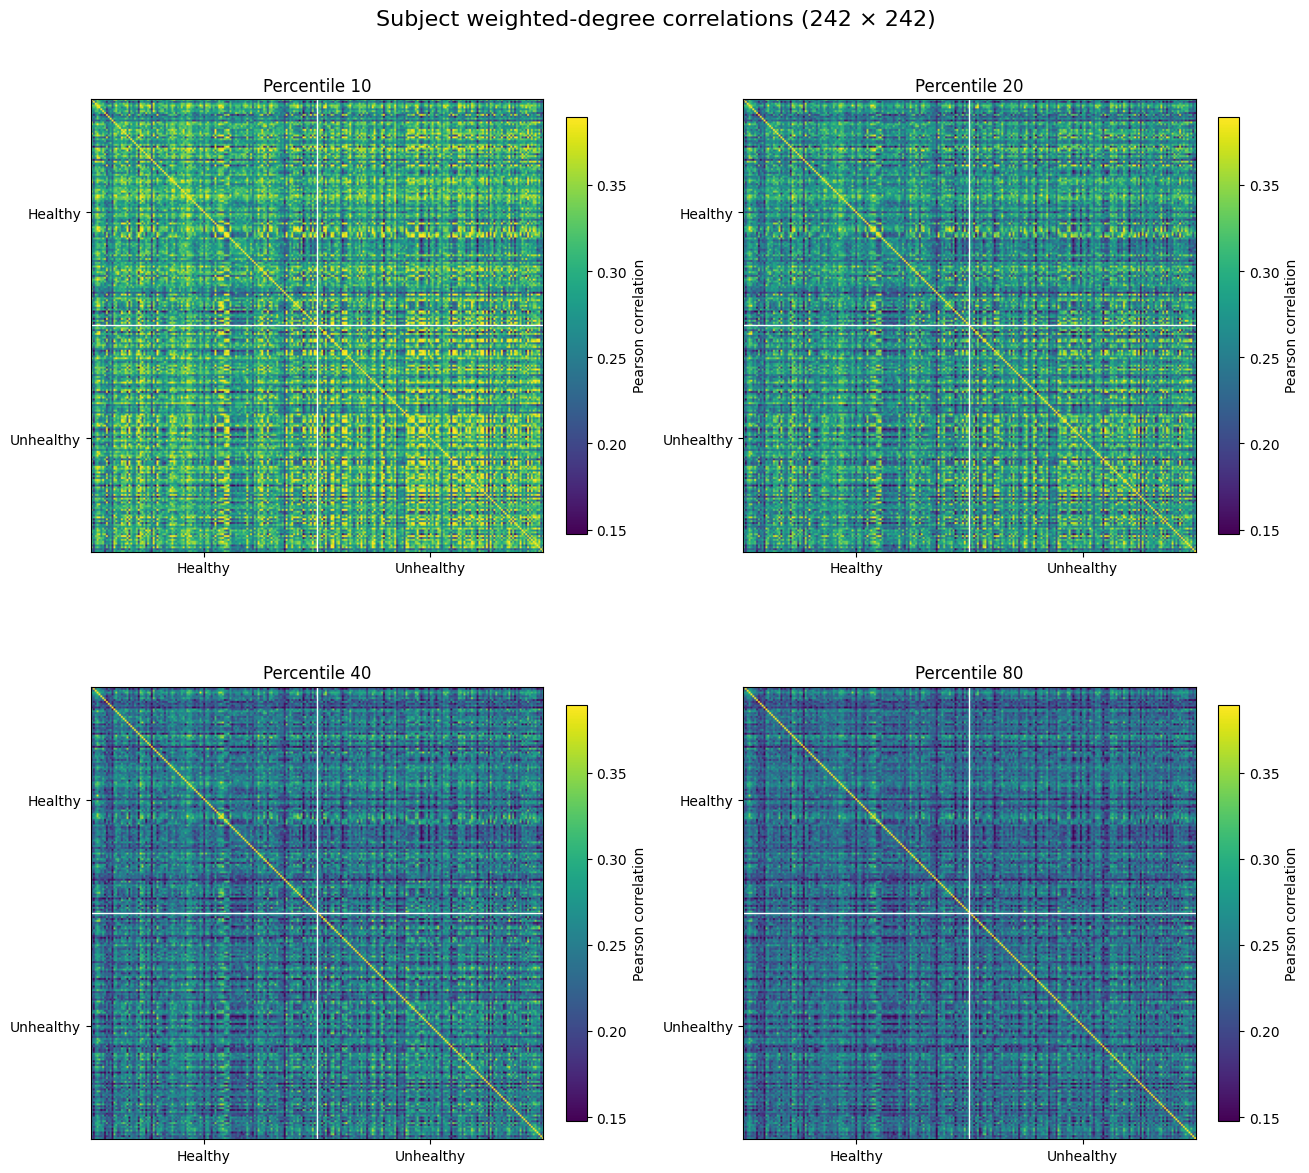

,percentile,mean_within_healthy_correlation,mean_within_unhealthy_correlation,mean_between_groups_correlation,within_minus_between_correlation
0,10,0.288522,0.299883,0.291360,0.002843
1,20,0.266427,0.276107,0.268798,0.002469
2,40,0.239797,0.246397,0.241071,0.002026
3,80,0.230507,0.233890,0.230446,0.001752


Saved figure: /home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/subject_weighted_degree_correlation_matrices.png


In [8]:
import matplotlib.pyplot as plt

SUBJECTS_PER_GROUP = 121
subject_correlation_matrices = {}
subject_correlation_summaries = []

for percentile_folder in percentile_folders:
    percentile = int(percentile_folder.name.removeprefix("percentile_"))
    subject_dirs = {
        folder.name: folder
        for folder in percentile_folder.glob("sub-*")
        if all((folder / name).is_file() for name in (
            "weighted_degree.dat", "parcel_order.txt", "metadata.json"
        ))
    }
    healthy_subjects = sorted(test_healthy & subject_dirs.keys())[:SUBJECTS_PER_GROUP]
    unhealthy_subjects = sorted(test_unhealthy & subject_dirs.keys())[:SUBJECTS_PER_GROUP]
    if len(healthy_subjects) != SUBJECTS_PER_GROUP or len(unhealthy_subjects) != SUBJECTS_PER_GROUP:
        raise ValueError(f"Need {SUBJECTS_PER_GROUP} subjects per group")

    parcel_ids = (subject_dirs[healthy_subjects[0]] / "parcel_order.txt").read_text().splitlines()
    degree_matrix = load_degree_matrix(
        healthy_subjects + unhealthy_subjects, subject_dirs, len(parcel_ids)
    )
    subject_correlation = np.corrcoef(degree_matrix)
    if not np.isfinite(subject_correlation).all():
        raise ValueError(f"Non-finite subject correlations at percentile {percentile}")
    subject_correlation_matrices[percentile] = subject_correlation
    split = SUBJECTS_PER_GROUP
    triangle = np.triu_indices(split, k=1)
    within_healthy = subject_correlation[:split, :split][triangle]
    within_unhealthy = subject_correlation[split:, split:][triangle]
    between_groups = subject_correlation[:split, split:].ravel()
    mean_within = np.concatenate((within_healthy, within_unhealthy)).mean()
    subject_correlation_summaries.append({
        "percentile": percentile,
        "mean_within_healthy_correlation": within_healthy.mean(),
        "mean_within_unhealthy_correlation": within_unhealthy.mean(),
        "mean_between_groups_correlation": between_groups.mean(),
        "within_minus_between_correlation": mean_within - between_groups.mean(),
    })
    del degree_matrix

off_diagonal_correlations = np.concatenate([
    matrix[~np.eye(len(matrix), dtype=bool)]
    for matrix in subject_correlation_matrices.values()
])
vmin, vmax = np.quantile(off_diagonal_correlations, [0.01, 0.99])

fig, axes = plt.subplots(2, 2, figsize=(13, 12), constrained_layout=True)
for axis, percentile in zip(axes.flat, sorted(subject_correlation_matrices)):
    correlations = subject_correlation_matrices[percentile]
    image = axis.imshow(
        correlations, cmap="viridis", vmin=vmin, vmax=vmax
    )
    axis.axhline(SUBJECTS_PER_GROUP - 0.5, color="white", linewidth=1)
    axis.axvline(SUBJECTS_PER_GROUP - 0.5, color="white", linewidth=1)
    group_centres = [
        (SUBJECTS_PER_GROUP - 1) / 2,
        SUBJECTS_PER_GROUP + (SUBJECTS_PER_GROUP - 1) / 2,
    ]
    axis.set_xticks(group_centres, ["Healthy", "Unhealthy"])
    axis.set_yticks(group_centres, ["Healthy", "Unhealthy"])
    axis.set_title(f"Percentile {percentile}")
    fig.colorbar(image, ax=axis, fraction=0.046, label="Pearson correlation")

fig.suptitle("Subject weighted-degree correlations (242 × 242)", fontsize=16)
correlation_figure_path = (
    THRESHOLDED_RESULTS_DIR / "subject_weighted_degree_correlation_matrices.png"
)
fig.savefig(correlation_figure_path, dpi=300, bbox_inches="tight")
plt.show()

subject_correlation_summary = pd.DataFrame(subject_correlation_summaries).sort_values("percentile")
display(subject_correlation_summary.round(6))
print(f"Saved figure: {correlation_figure_path}")


## Subject-by-subject correlations for the full test cohort

This version has no 121-subject-per-group cap. At each percentile it uses every Healthy and Unhealthy subject from the JSON test cohort with complete thresholded weighted-degree outputs.

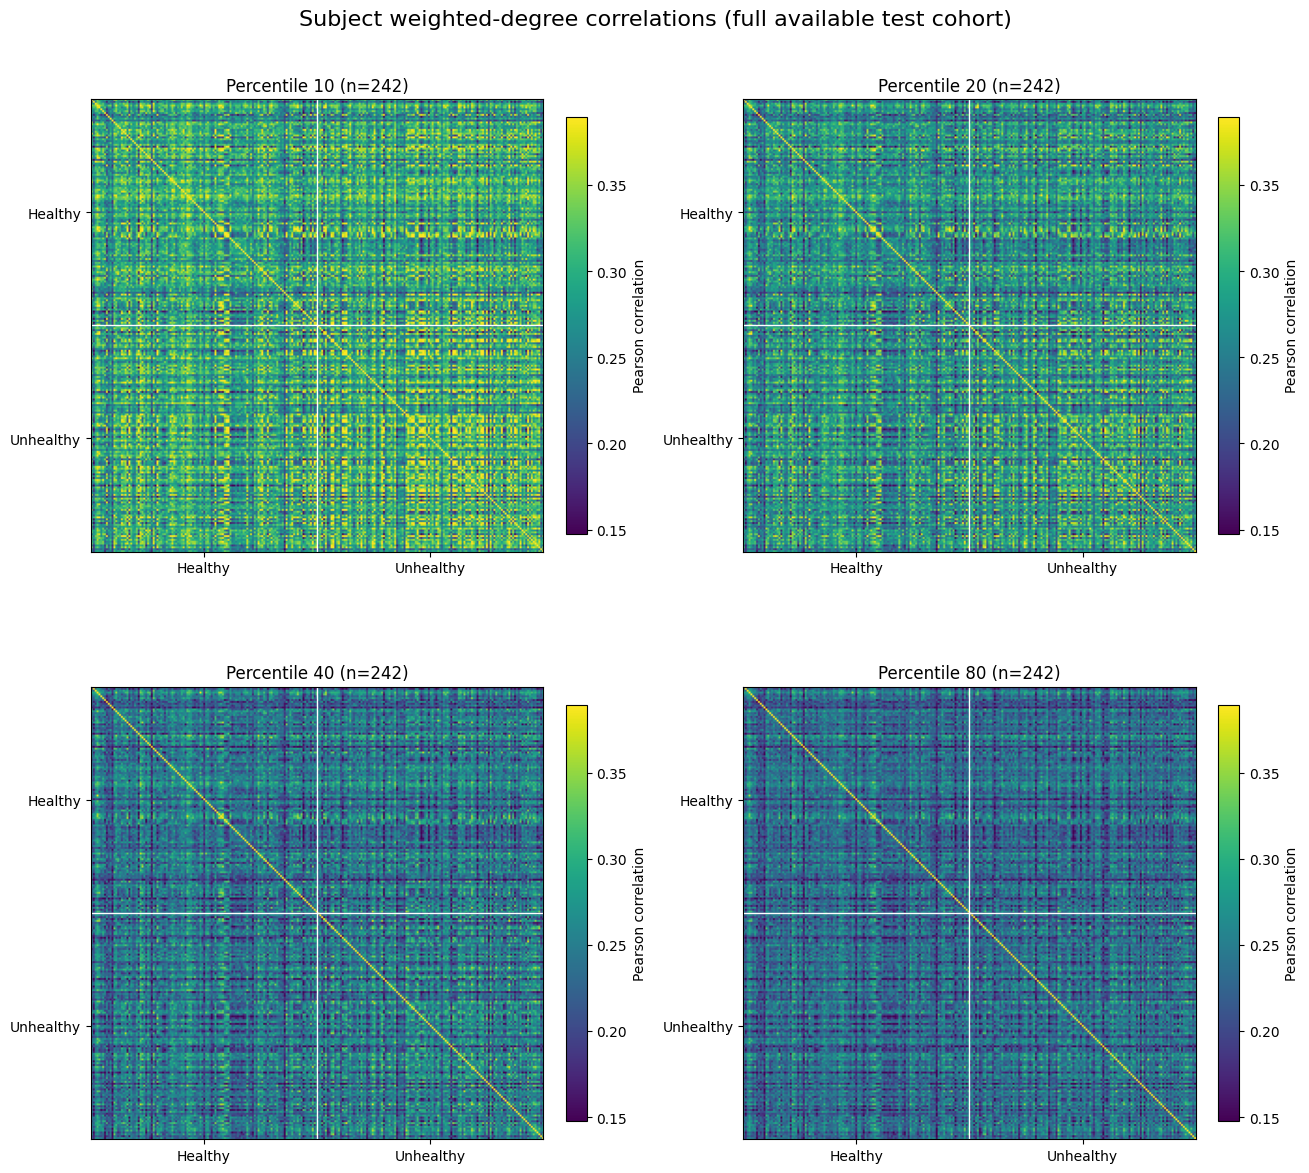

,percentile,healthy_subjects,unhealthy_subjects,healthy_missing_complete_outputs,unhealthy_missing_complete_outputs,mean_within_healthy_correlation,mean_within_unhealthy_correlation,mean_between_groups_correlation,within_minus_between_correlation
0,10,121,121,29,29,0.288522,0.299883,0.291360,0.002843
1,20,121,121,29,29,0.266427,0.276107,0.268798,0.002469
2,40,121,121,29,29,0.239797,0.246397,0.241071,0.002026
3,80,121,121,29,29,0.230507,0.233890,0.230446,0.001752


Saved figure: /home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/subject_weighted_degree_correlation_matrices_full_cohort.png


In [9]:
full_cohort_correlation_matrices = {}
full_cohort_correlation_summaries = []
full_cohort_group_sizes = {}

for percentile_folder in percentile_folders:
    percentile = int(percentile_folder.name.removeprefix("percentile_"))
    subject_dirs = {
        folder.name: folder
        for folder in percentile_folder.glob("sub-*")
        if all((folder / name).is_file() for name in (
            "weighted_degree.dat", "parcel_order.txt", "metadata.json"
        ))
    }
    healthy_subjects = sorted(test_healthy & subject_dirs.keys())
    unhealthy_subjects = sorted(test_unhealthy & subject_dirs.keys())
    if len(healthy_subjects) < 2 or len(unhealthy_subjects) < 2:
        raise ValueError(f"Insufficient subjects at percentile {percentile}")

    all_subjects = healthy_subjects + unhealthy_subjects
    parcel_ids = (
        subject_dirs[all_subjects[0]] / "parcel_order.txt"
    ).read_text().splitlines()
    degree_matrix = load_degree_matrix(
        all_subjects, subject_dirs, len(parcel_ids)
    )
    subject_correlation = np.corrcoef(degree_matrix)
    if not np.isfinite(subject_correlation).all():
        raise ValueError(
            f"Non-finite full-cohort correlations at percentile {percentile}"
        )

    healthy_count = len(healthy_subjects)
    unhealthy_count = len(unhealthy_subjects)
    full_cohort_correlation_matrices[percentile] = subject_correlation
    full_cohort_group_sizes[percentile] = (healthy_count, unhealthy_count)

    healthy_triangle = np.triu_indices(healthy_count, k=1)
    unhealthy_triangle = np.triu_indices(unhealthy_count, k=1)
    within_healthy = subject_correlation[
        :healthy_count, :healthy_count
    ][healthy_triangle]
    within_unhealthy = subject_correlation[
        healthy_count:, healthy_count:
    ][unhealthy_triangle]
    between_groups = subject_correlation[:healthy_count, healthy_count:].ravel()
    mean_within = np.concatenate((within_healthy, within_unhealthy)).mean()
    full_cohort_correlation_summaries.append({
        "percentile": percentile,
        "healthy_subjects": healthy_count,
        "unhealthy_subjects": unhealthy_count,
        "healthy_missing_complete_outputs": len(test_healthy) - healthy_count,
        "unhealthy_missing_complete_outputs": len(test_unhealthy) - unhealthy_count,
        "mean_within_healthy_correlation": within_healthy.mean(),
        "mean_within_unhealthy_correlation": within_unhealthy.mean(),
        "mean_between_groups_correlation": between_groups.mean(),
        "within_minus_between_correlation": (
            mean_within - between_groups.mean()
        ),
    })
    del degree_matrix

full_cohort_off_diagonal = np.concatenate([
    matrix[~np.eye(len(matrix), dtype=bool)]
    for matrix in full_cohort_correlation_matrices.values()
])
full_vmin, full_vmax = np.quantile(
    full_cohort_off_diagonal, [0.01, 0.99]
)

fig, axes = plt.subplots(2, 2, figsize=(13, 12), constrained_layout=True)
for axis, percentile in zip(
    axes.flat, sorted(full_cohort_correlation_matrices)
):
    correlations = full_cohort_correlation_matrices[percentile]
    healthy_count, unhealthy_count = full_cohort_group_sizes[percentile]
    image = axis.imshow(
        correlations, cmap="viridis", vmin=full_vmin, vmax=full_vmax
    )
    axis.axhline(healthy_count - 0.5, color="white", linewidth=1)
    axis.axvline(healthy_count - 0.5, color="white", linewidth=1)
    group_centres = [
        (healthy_count - 1) / 2,
        healthy_count + (unhealthy_count - 1) / 2,
    ]
    axis.set_xticks(group_centres, ["Healthy", "Unhealthy"])
    axis.set_yticks(group_centres, ["Healthy", "Unhealthy"])
    axis.set_title(
        f"Percentile {percentile} (n={healthy_count + unhealthy_count})"
    )
    fig.colorbar(image, ax=axis, fraction=0.046, label="Pearson correlation")

fig.suptitle(
    "Subject weighted-degree correlations (full available test cohort)",
    fontsize=16,
)
full_cohort_figure_path = (
    THRESHOLDED_RESULTS_DIR
    / "subject_weighted_degree_correlation_matrices_full_cohort.png"
)
fig.savefig(full_cohort_figure_path, dpi=300, bbox_inches="tight")
plt.show()

full_cohort_correlation_summary = (
    pd.DataFrame(full_cohort_correlation_summaries).sort_values("percentile")
)
display(full_cohort_correlation_summary.round(6))
print(f"Saved figure: {full_cohort_figure_path}")


## Split-cohort correlations on BH-FDR-significant parcels

For each percentile, this descriptive plot uses the 121 Healthy and 121 Unhealthy subjects selected through data/splits.json, but computes subject correlations using only the parcels surviving that percentile's 121-vs-121 Welch/BH-FDR test.

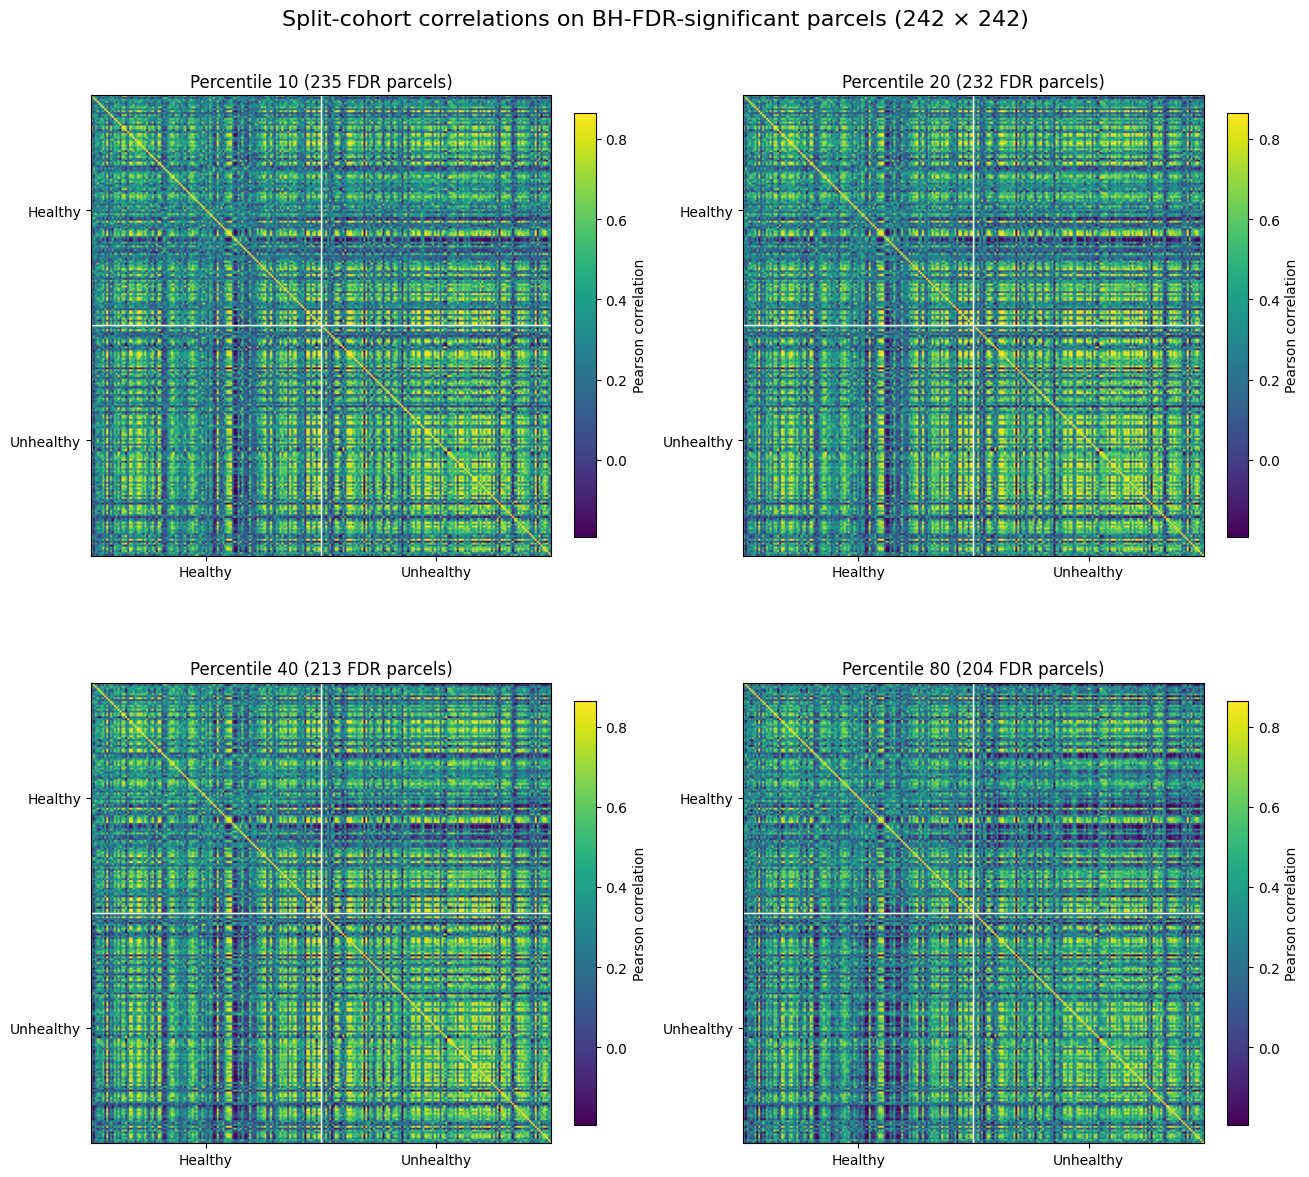

,percentile,healthy_subjects,unhealthy_subjects,bh_fdr_significant_parcels,mean_within_healthy_correlation,mean_within_unhealthy_correlation,mean_between_groups_correlation,within_minus_between_correlation
0,10,121,121,235,0.323782,0.381179,0.331519,0.020961
1,20,121,121,232,0.328586,0.393896,0.336553,0.024689
2,40,121,121,213,0.335364,0.393153,0.328624,0.035635
3,80,121,121,204,0.311436,0.363079,0.292071,0.045187


Saved figure: /home/lucagalli/Projects/parcellating_dbm/outputs/statistics_thresholded_weighted_degree/subject_weighted_degree_correlation_matrices_fdr_parcels.png


In [10]:
FDR_CORRELATION_SUBJECTS_PER_GROUP = 121
fdr_correlation_matrices = {}
fdr_correlation_summaries = []
fdr_significant_parcel_counts = {}

for percentile_folder in percentile_folders:
    percentile = int(percentile_folder.name.removeprefix("percentile_"))
    subject_dirs = {
        folder.name: folder
        for folder in percentile_folder.glob("sub-*")
        if all((folder / name).is_file() for name in (
            "weighted_degree.dat", "parcel_order.txt", "metadata.json"
        ))
    }
    healthy_subjects = sorted(test_healthy & subject_dirs.keys())
    unhealthy_subjects = sorted(test_unhealthy & subject_dirs.keys())
    if (
        len(healthy_subjects) != FDR_CORRELATION_SUBJECTS_PER_GROUP
        or len(unhealthy_subjects) != FDR_CORRELATION_SUBJECTS_PER_GROUP
    ):
        raise ValueError(
            f"Expected 121 Healthy and 121 Unhealthy subjects at percentile "
            f"{percentile}; found {len(healthy_subjects)} and "
            f"{len(unhealthy_subjects)}"
        )

    split_subjects = healthy_subjects + unhealthy_subjects
    parcel_ids = (
        subject_dirs[split_subjects[0]] / "parcel_order.txt"
    ).read_text().splitlines()
    degree_matrix = load_degree_matrix(
        split_subjects, subject_dirs, len(parcel_ids)
    )

    fdr_results_path = (
        THRESHOLDED_RESULTS_DIR
        / percentile_folder.name
        / "thresholded_weighted_degree_independent_welch_tests.csv"
    )
    fdr_results = pd.read_csv(fdr_results_path)
    if fdr_results["parcel_id"].astype(str).tolist() != parcel_ids:
        raise ValueError(
            f"FDR result parcel order differs at percentile {percentile}"
        )
    fdr_mask = (
        fdr_results["welch_q_bh"].to_numpy(dtype=float) < 0.05
    )
    significant_parcel_count = int(fdr_mask.sum())
    if significant_parcel_count < 2:
        raise ValueError(
            f"Need at least two BH-FDR-significant parcels at percentile "
            f"{percentile}; found {significant_parcel_count}"
        )

    significant_degree_matrix = degree_matrix[:, fdr_mask]
    subject_correlation = np.corrcoef(significant_degree_matrix)
    if not np.isfinite(subject_correlation).all():
        raise ValueError(
            f"Non-finite FDR-parcel correlations at percentile {percentile}"
        )

    fdr_correlation_matrices[percentile] = subject_correlation
    fdr_significant_parcel_counts[percentile] = significant_parcel_count
    split = FDR_CORRELATION_SUBJECTS_PER_GROUP
    triangle = np.triu_indices(split, k=1)
    within_healthy = subject_correlation[:split, :split][triangle]
    within_unhealthy = subject_correlation[split:, split:][triangle]
    between_groups = subject_correlation[:split, split:].ravel()
    mean_within = np.concatenate((within_healthy, within_unhealthy)).mean()
    fdr_correlation_summaries.append({
        "percentile": percentile,
        "healthy_subjects": len(healthy_subjects),
        "unhealthy_subjects": len(unhealthy_subjects),
        "bh_fdr_significant_parcels": significant_parcel_count,
        "mean_within_healthy_correlation": within_healthy.mean(),
        "mean_within_unhealthy_correlation": within_unhealthy.mean(),
        "mean_between_groups_correlation": between_groups.mean(),
        "within_minus_between_correlation": (
            mean_within - between_groups.mean()
        ),
    })
    del degree_matrix, significant_degree_matrix, fdr_results

fdr_off_diagonal_correlations = np.concatenate([
    matrix[~np.eye(len(matrix), dtype=bool)]
    for matrix in fdr_correlation_matrices.values()
])
fdr_vmin, fdr_vmax = np.quantile(
    fdr_off_diagonal_correlations, [0.01, 0.99]
)

fig, axes = plt.subplots(2, 2, figsize=(13, 12), constrained_layout=True)
for axis, percentile in zip(
    axes.flat, sorted(fdr_correlation_matrices)
):
    correlations = fdr_correlation_matrices[percentile]
    image = axis.imshow(
        correlations, cmap="viridis", vmin=fdr_vmin, vmax=fdr_vmax
    )
    axis.axhline(
        FDR_CORRELATION_SUBJECTS_PER_GROUP - 0.5,
        color="white",
        linewidth=1,
    )
    axis.axvline(
        FDR_CORRELATION_SUBJECTS_PER_GROUP - 0.5,
        color="white",
        linewidth=1,
    )
    group_centres = [
        (FDR_CORRELATION_SUBJECTS_PER_GROUP - 1) / 2,
        FDR_CORRELATION_SUBJECTS_PER_GROUP
        + (FDR_CORRELATION_SUBJECTS_PER_GROUP - 1) / 2,
    ]
    axis.set_xticks(group_centres, ["Healthy", "Unhealthy"])
    axis.set_yticks(group_centres, ["Healthy", "Unhealthy"])
    axis.set_title(
        f"Percentile {percentile} "
        f"({fdr_significant_parcel_counts[percentile]} FDR parcels)"
    )
    fig.colorbar(image, ax=axis, fraction=0.046, label="Pearson correlation")

fig.suptitle(
    "Split-cohort correlations on BH-FDR-significant parcels (242 × 242)",
    fontsize=16,
)
fdr_correlation_figure_path = (
    THRESHOLDED_RESULTS_DIR
    / "subject_weighted_degree_correlation_matrices_fdr_parcels.png"
)
fig.savefig(fdr_correlation_figure_path, dpi=300, bbox_inches="tight")
plt.show()

fdr_correlation_summary = (
    pd.DataFrame(fdr_correlation_summaries).sort_values("percentile")
)
display(fdr_correlation_summary.round(6))
print(f"Saved figure: {fdr_correlation_figure_path}")
